# 여성의류 리뷰 데이터 EDA 실습 노트북

이 노트북에서는 여성의류 라벨링 데이터(JSON)를 이용해 다음과 같은 탐색적 데이터 분석(EDA)을 수행합니다.

1. 데이터 기본 구조 및 결측치 확인
2. 리뷰 길이(문자 수, 단어 수) 분포 분석
3. 리뷰 날짜 분포 분석
4. ReviewScore 분포 및 길이와의 관계
5. GeneralPolarity(전체 감성) 분포 분석
6. Aspect 기반 EDA (Aspect 빈도, Aspect별 감성 분포, 사이즈/가격 vs ReviewScore)
7. N-gram / TF-IDF 기반 텍스트 분석
8. Aspect별 대표 문장 살펴보기

> **주의:** 아래 경로(`JSON_PATH`)를 본인의 파일 경로에 맞게 수정한 뒤 실행하세요.

In [9]:
!apt-get install -y fonts-nanum
!rm -rf /root/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [7]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib import rc

# 1. 실제 폰트 파일 경로 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# 2. 폰트 이름 얻기 (matplotlib 내부명)
font_name = fm.FontProperties(fname=font_path).get_name()
print("matplotlib이 인식한 폰트 이름:", font_name)

# 3. 폰트 적용
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

matplotlib이 인식한 폰트 이름: NanumGothic


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from wordcloud import WordCloud
# N-gram, TF-IDF용 라이브러리
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 한글 폰트 (환경에 따라 변경 필요)
# plt.rcParams['axes.unicode_minus'] = False

# JSON 파일 경로를 본인 환경에 맞게 수정하세요.
JSON_PATH = Path(r'/content/drive/MyDrive/multicampus/자연어처리/woman_wear_balanced_stream_600_each.json')  # 예시


## 1. 데이터 로드 및 기본 정보 확인

In [17]:
df=pd.read_json(JSON_PATH, encoding="utf-8")
df.head()

,Index,RawText,Source,Domain,MainCategory,ProductName,ReviewScore,Syllable,Word,RDate,GeneralPolarity,Aspects
0,44108,신축성은 정말 좋지만 핏이 영~~. 3벌중에 한개만 핏이 이쁘고 두개는 핏이 영~~...,쇼핑몰,패션,여성의류,OO 여성 매** 데님 3종,60,148,32,20180412,-1,"[{'Aspect': '신축성', 'SentimentText': '신축성은 정말 좋..."
1,44121,아주편하고좋아요..근데..허리쪽바느질이엉망이라자꾸까슬거려요..불량인듯한데교환귀찮아서...,쇼핑몰,패션,여성의류,OO 여성 매** 데님 3종,80,51,1,20180328,-1,"[{'Aspect': '착용감', 'SentimentText': '아주편하고좋아요...."
2,44000,기존32-34사이즈 입습니다 탄력성이좋다해서 30사이즈구매했는데 밴드없는건안들어가고...,쇼핑몰,패션,여성의류,OO 여성 데일리 데님 3종,20,198,24,20180302,-1,"[{'Aspect': '사이즈', 'SentimentText': '밴드없는건안들어가..."
3,44138,사이즈가 다 조금씩다르네요. 크게차이는 없는거같긴한데.. 허리밸트부분은 신축성이 별...,쇼핑몰,패션,여성의류,OO 여성 미** 에어데님 3종,60,50,8,20180309,-1,"[{'Aspect': '사이즈', 'SentimentText': '사이즈가 다 조금..."
4,44063,바지 옆라인이 자꾸 앞쪽으로 틀어져 다리가 휜것처럼보여요. 청바지 만들때 스트레치가...,쇼핑몰,패션,여성의류,OO 여성 웨** 진 3종,60,99,20,20180321,-1,"[{'Aspect': '품질', 'SentimentText': '바지 옆라인이 자꾸..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Index            1800 non-null   int64 
 1   RawText          1800 non-null   object
 2   Source           1800 non-null   object
 3   Domain           1800 non-null   object
 4   MainCategory     1800 non-null   object
 5   ProductName      1800 non-null   object
 6   ReviewScore      1800 non-null   int64 
 7   Syllable         1800 non-null   int64 
 8   Word             1800 non-null   int64 
 9   RDate            1800 non-null   int64 
 10  GeneralPolarity  1800 non-null   int64 
 11  Aspects          1800 non-null   object
dtypes: int64(6), object(6)
memory usage: 168.9+ KB


In [6]:
df.isna().sum()

,0
Index,0
RawText,0
Source,0
Domain,0
MainCategory,0
ProductName,0
ReviewScore,0
Syllable,0
Word,0
RDate,0


## 2. 리뷰 길이 분석 (문자 수, 단어 수)

- RawText 길이(문자 수)
- RawText 단어 수
- 길이 분포 히스토그램 / 박스플롯

In [18]:
# df["text_len"] = df["RawText"].astype(str).apply(lambda x: len(x))
df["text_len"] = df["RawText"].astype(str).apply(len)
df['text_len'].describe()

,text_len
count,1800.000000
mean,77.191111
std,47.230410
min,8.000000
25%,43.000000
50%,64.000000
75%,99.000000
max,444.000000


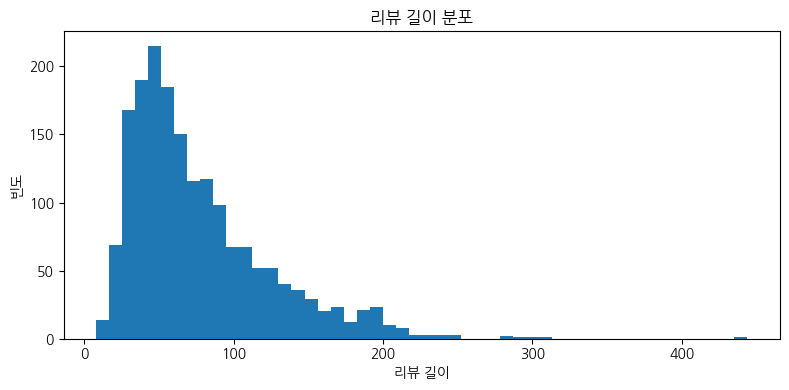

In [11]:
plt.figure(figsize=(8,4))
plt.hist(df["text_len"], bins=50)
plt.title("리뷰 길이 분포")
plt.xlabel("리뷰 길이")
plt.ylabel("빈도")
plt.tight_layout()
plt.show()

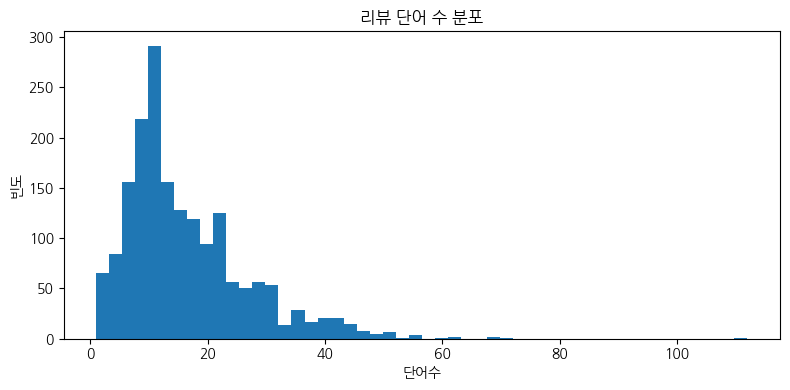

In [12]:
plt.figure(figsize=(8,4))
plt.hist(df["Word"], bins=50)
plt.title("리뷰 단어 수 분포")
plt.xlabel("단어수")
plt.ylabel("빈도")
plt.tight_layout()
plt.show()

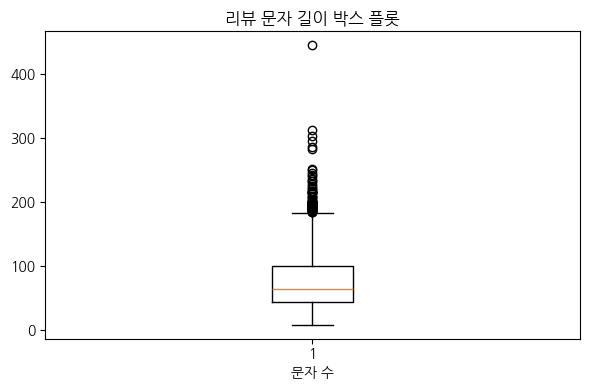

In [13]:
plt.figure(figsize=(6,4))
plt.boxplot(df["text_len"])
plt.title("리뷰 문자 길이 박스 플롯")
plt.xlabel("문자 수")
plt.tight_layout()
plt.show()

## 3. 리뷰 날짜(RDate) 분포

- 날짜 컬럼을 datetime으로 변환
- 전체 기간 동안 리뷰가 어떻게 분포하는지 확인

In [19]:
df["date"] = pd.to_datetime(df["RDate"].astype(str))
df['date'].describe()


,date
count,1800
mean,2019-07-27 11:27:11.999999744
min,2018-02-24 00:00:00
25%,2018-12-08 00:00:00
50%,2019-04-22 00:00:00
75%,2020-03-30 00:00:00
max,2022-03-01 00:00:00


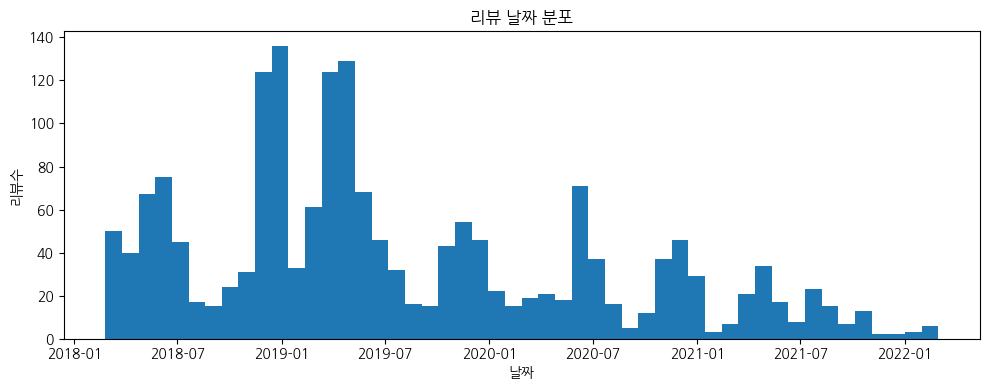

In [22]:
plt.figure(figsize=(10,4))
plt.hist(df["date"].dropna(), bins=50)
plt.title("리뷰 날짜 분포")
plt.xlabel("날짜")
plt.ylabel("리뷰수")
plt.tight_layout()
plt.show()

## 4. ReviewScore 분포 및 길이와의 관계

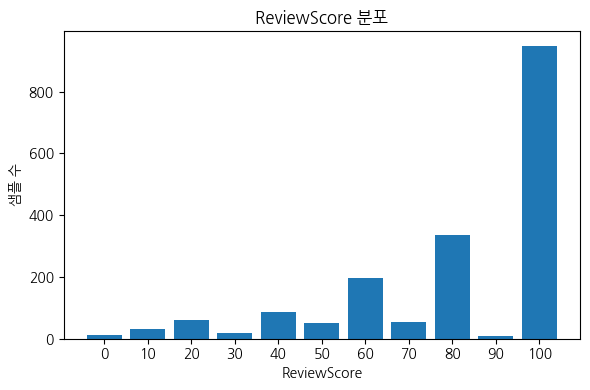

In [27]:
scores = df['ReviewScore'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(scores.index.astype(str), scores.values)
plt.title("ReviewScore 분포")
plt.xlabel("ReviewScore")
plt.ylabel("샘플 수")
plt.tight_layout()
plt.show()


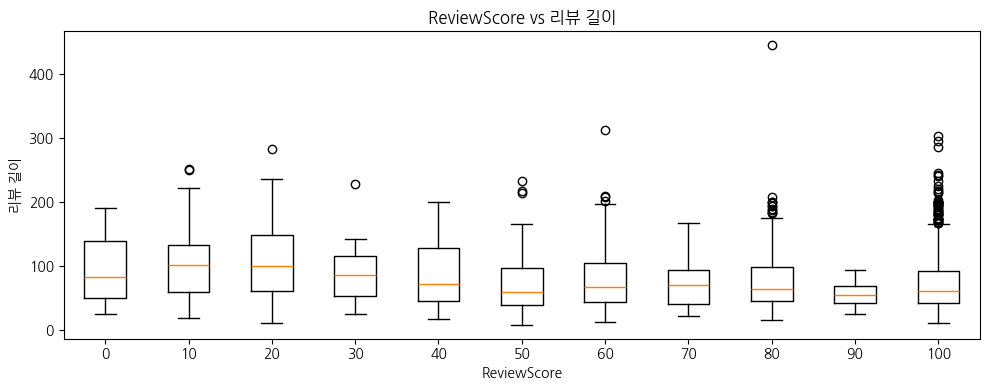

In [31]:
data = [ df[df['ReviewScore'] == s]['text_len'] for s in sorted(df['ReviewScore'].unique()) ]

plt.figure(figsize=(10,4))
plt.boxplot(data, tick_labels=sorted(df['ReviewScore'].unique()))
plt.title("ReviewScore vs 리뷰 길이")
plt.xlabel("ReviewScore")
plt.ylabel("리뷰 길이")
plt.tight_layout()
plt.show()

## 5. GeneralPolarity(전체 감성) 분포

- -1: 부정, 0: 중립, 1: 긍정

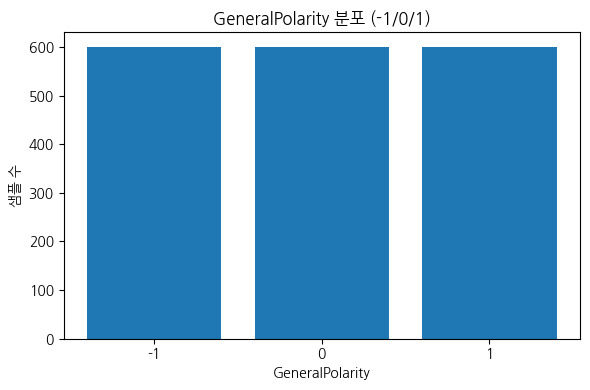

In [35]:
gp_counts = df['GeneralPolarity'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(gp_counts.index.astype(str), gp_counts.values)
plt.title('GeneralPolarity 분포 (-1/0/1)')
plt.xlabel('GeneralPolarity')
plt.ylabel('샘플 수')
plt.tight_layout()
plt.show()

## 6. Aspect 기반 EDA

- Aspects 컬럼을 행 단위로 풀어서 하나의 DataFrame(`aspect_df`) 생성
- Aspect 종류별 빈도
- Aspect별 감성 분포(-1/0/1)
- "사이즈" / "가격"에 대한 감성과 ReviewScore 관계 보기

In [38]:
aspect_rows = []

for _, row in df.dropna(subset=["Aspects"]).iterrows():
  aspects = row['Aspects']
  if not isinstance(aspects, list):
      continue
  for a in aspects:
    aspect_rows.append({
            'Aspect': a.get("Aspect"),
            'ReviewScore': row['ReviewScore'],
            'SentimentPolarity': a.get("SentimentPolarity"),
            "SentimentText":a.get("SentimentText"),
        })

aspect_df = pd.DataFrame(aspect_rows)
aspect_df.head()

,Aspect,ReviewScore,SentimentPolarity,SentimentText
0,신축성,60,1,신축성은 정말 좋지만
1,핏,60,-1,핏이 영~~.
2,핏,60,1,3벌중에 한개만 핏이 이쁘고
3,핏,60,-1,두개는 핏이 영~~아니네요.
4,품질,60,-1,품질이 싼티 마니남.


In [39]:
aspect_counts = aspect_df['Aspect'].value_counts()
aspect_counts

,count
Aspect,
사이즈,1466
착용감,757
핏,606
기능,585
신축성,546
품질,438
길이,434
디자인,386
두께,373


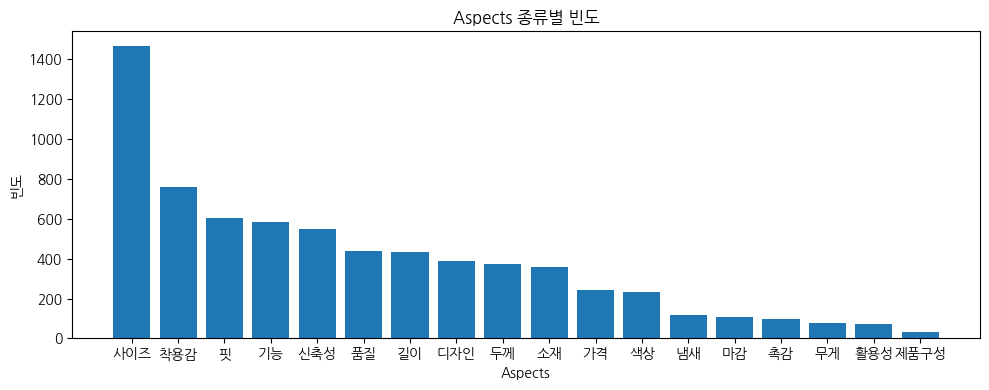

In [40]:
plt.figure(figsize=(10, 4))
plt.bar(aspect_counts.index, aspect_counts.values)
plt.title('Aspects 종류별 빈도')
plt.xlabel('Aspects')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

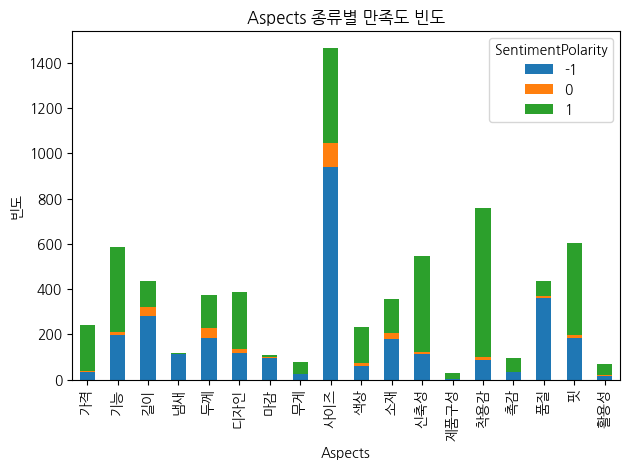

In [43]:
aspect_pivot = aspect_df.groupby(['Aspect', "SentimentPolarity"])['SentimentPolarity'].count()
aspect_pivot.unstack().plot(kind="bar", stacked=True)
plt.title('Aspects 종류별 만족도 빈도')
plt.xlabel('Aspects')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()


In [44]:
size_df = aspect_df[aspect_df['Aspect'] == '사이즈']
size_df["SentimentPolarity"].value_counts()

,count
SentimentPolarity,
-1,940
1,418
0,108


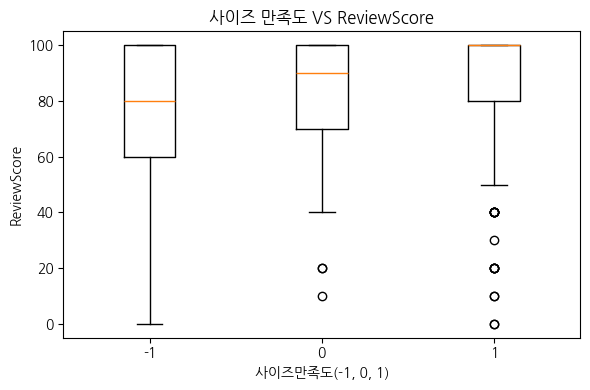

In [45]:
data = [ size_df[size_df['SentimentPolarity']==s]['ReviewScore']  for s in sorted(size_df['SentimentPolarity'].unique())]

labels = sorted(size_df['SentimentPolarity'].unique())
plt.figure(figsize=(6, 4))
plt.boxplot(data, tick_labels=labels)
plt.title('사이즈 만족도 VS ReviewScore')
plt.xlabel('사이즈만족도(-1, 0, 1)')
plt.ylabel('ReviewScore')
plt.tight_layout()
plt.show()

In [46]:
price_df = aspect_df[aspect_df['Aspect'] == '가격']
price_df["SentimentPolarity"].value_counts()

,count
SentimentPolarity,
1,204
-1,33
0,5


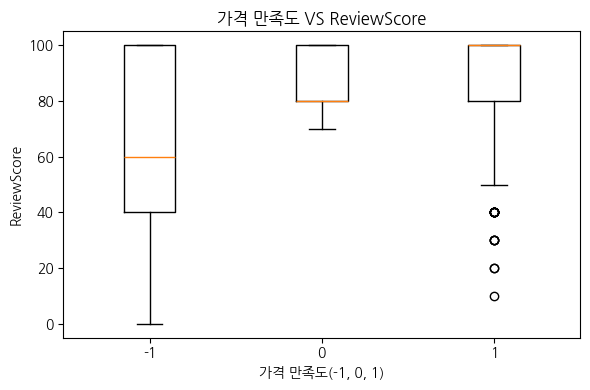

In [47]:
data = [ price_df[price_df['SentimentPolarity']==s]['ReviewScore']  for s in sorted(price_df['SentimentPolarity'].unique())]

labels = sorted(price_df['SentimentPolarity'].unique())
plt.figure(figsize=(6, 4))
plt.boxplot(data, tick_labels=labels)
plt.title('가격 만족도 VS ReviewScore')
plt.xlabel('가격 만족도(-1, 0, 1)')
plt.ylabel('ReviewScore')
plt.tight_layout()
plt.show()

## 7. 텍스트 기반 분석: N-gram(CountVectorizer) / TF-IDF(긍/부정 상위 20개 단어 추출)

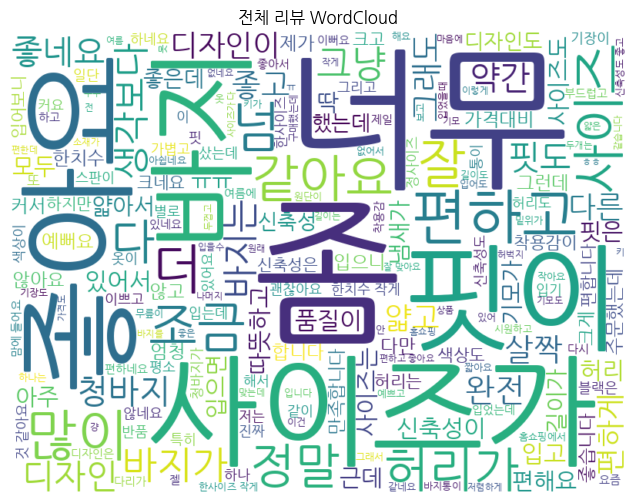

In [67]:
text_all = " ".join(df["RawText"].astype(str))
# print(type(text_all))
wc = WordCloud(background_color="white", width=800, height=600, font_path=font_path).generate(text_all)
plt.figure(figsize=(8,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("전체 리뷰 WordCloud")
plt.show()

In [52]:
vec = CountVectorizer(ngram_range=(2, 2), max_features=1000)
X_ngrams = vec.fit_transform(df['RawText'].astype(str))

ngram_freq = np.array(X_ngrams.sum(axis=0))[0]
ngram_word = vec.get_feature_names_out()

ngram_df = pd.DataFrame({"ngram":ngram_word, "freq":ngram_freq})
ngram_df = ngram_df.sort_values('freq', ascending=False).head(20)
ngram_df

,ngram,freq
980,한치수 작게,34
207,맘에 들어요,26
977,한사이즈 작게,24
460,신축성도 좋고,21
891,편하고 좋아요,21
208,맘에 듭니다,19
476,신축성이 좋아서,18
707,저렴한 가격에,18
68,귀찮아서 그냥,14
250,바지 길이가,13


In [54]:
neg_texts = df[df['GeneralPolarity'] == -1]['RawText'].astype(str)

if len(neg_texts) > 0:
  tfidf = TfidfVectorizer(ngram_range=(2,2),max_features=20)
  X_tfidf = tfidf.fit_transform(neg_texts)

  tfidf_val = np.array(X_tfidf.sum(axis=0))[0]
  tfidf_word = tfidf.get_feature_names_out()

  tfidf_df = pd.DataFrame({"word":tfidf_word, "val":tfidf_val})
  tfidf_df = tfidf_df.sort_values('val', ascending=False).head(20)
  print(tfidf_df)
else:
  print("부정 리뷰가 없어 계산할수 없습니다.")


         word       val
2      냄새가 너무  7.982224
0     귀찮아서 그냥  7.678518
18     한치수 작게  6.676583
14   사이즈가 달라요  6.353166
9      바지 길이가  4.695705
13  사이즈가 다르네요  4.695705
1      그냥 입어요  4.220040
15    사이즈가 커서  4.000000
16     전혀 없어서  3.750614
12    반품도 못하고  3.750614
10    바지 사이즈가  3.736366
3     냄새가 심해서  3.707107
4     냄새가 심해요  3.707107
17    편하고 좋은데  3.693613
8     마음에 듭니다  3.501227
19    허리 사이즈가  3.472733
11     반품 귀찮아  3.436655
5   너무 실망스럽네요  3.000000
7       너무 커요  3.000000
6       너무 커서  2.720348


## 8. Aspect별 대표 문장(길이기준) 살펴보기

- 사이즈 부정 문장 Top 20
- 가격 긍정 문장 Top 20

In [59]:
size_neg = aspect_df[(aspect_df["Aspect"]=="사이즈") & (aspect_df["SentimentPolarity"] == "-1")].copy()

size_neg['text_len'] = size_neg['SentimentText'].astype(str).apply(len)
top_size_neg = size_neg.sort_values('text_len', ascending=False).head(20)
top_size_neg

,Aspect,ReviewScore,SentimentPolarity,SentimentText,text_len
3469,사이즈,100,-1,보통 허리27정도 입는데 이 청바지는 스판이 많아 좀 타이트하게 입어도 될듯해요,46
3677,사이즈,100,-1,두번째가 어두운 바지이고 마지막으로 블랙이 제일 작게 느껴졌어요 ㅋㅋㅋㅋ,41
2338,사이즈,100,-1,평소 27~28사이즈 입는데 26주문했어요~~몸에 꼭맞는 핏이 되었네요..,41
3258,사이즈,100,-1,허리가 살짝 타이트하지만 30이아닌 28을 주문해서 감안하고 입어요~~,39
3838,사이즈,100,-1,사이즈가 55~66이라 그런지 통통 55인데 어깨가 조금 많이 크네요,39
1560,사이즈,10,-1,바지에 세개다 같은 사이즈 택이 붙어 있는데 이렇게 다를 수가 있나요,39
4437,사이즈,100,-1,29 입는데 28 주문 했는데 그런데도 아주 넉넉하다고 해야 하나..,39
540,사이즈,100,-1,허리가 너무커서 바지지퍼를 내리지않고 그냥입어도 넉넉하게입을수가있네요,38
1941,사이즈,80,-1,사이즈표에 나와있는 허리사이즈랑 실제 바지의 허리사이즈가 다릅니다.,38
811,사이즈,20,-1,바지가 줄줄내려가서 집에와 사이즈보니 허리가 차이가 많이 나는데,38


In [60]:
price_pos = aspect_df[(aspect_df["Aspect"]=="가격") & (aspect_df["SentimentPolarity"] == "1")].copy()

price_pos['text_len'] = price_pos['SentimentText'].astype(str).apply(len)
top_price_pos = price_pos.sort_values('text_len', ascending=False).head(20)
top_price_pos

,Aspect,ReviewScore,SentimentPolarity,SentimentText,text_len
3283,가격,60,1,저렴한 가격에 구입한 거라 그걸로 만족하겠습니다.,27
2551,가격,60,1,청바지세개를 이가격에 쌀수있으니 그냥만족하려구요.,27
3332,가격,100,1,저렴한 금액으로 그정도는 교환없이 입기로 했어요.,27
4582,가격,100,1,가격도 저렴하게 잘 산것 같아서 아주 만족해요~,26
3248,가격,100,1,적립금이랑 쿠폰사용 넘 착한 금액에 구입해서,24
407,가격,100,1,저렴한 가격으로 구매하게 되어 만족합니다.,24
3504,가격,60,1,쿠폰이용 싸게 사서 그냥 입기로 결정합니다,23
575,가격,80,1,이 가격에 청바지 두벌. 거짓말 같네요^^,23
5447,가격,100,1,무튼 좋은제품 저렴한 가격으로 득템했습니다,23
4873,가격,100,1,가격도 너무 부담스럽지 않아서 좋아요~~~,23
